In [19]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
import datetime as dt
import Engine as Ctool
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import math
from scipy.optimize import minimize
import cvxpy as cp
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

In [20]:
start_date = dt.date(2017, 1, 1)
end_date = dt.date(2022, 12, 31)

In [21]:
universe = Ctool.load_universe("SP500", start_date, end_date)["SP500"]
universe = [tickers.split(',') for tickers in universe.tickers.values]
universe = list({ticker for tickers in universe for ticker in tickers})

In [22]:
alpha_dict = {}
master_index = Ctool.calc_business_date(start_date, end_date)
for ticker in universe:
    ticker_data = Ctool.calc_forward_close(ticker, Ctool.calc_add_date(start_date, "-60b"), end_date)[ticker]
    ticker_data['value'] = ticker_data['adjusted_close'] - ticker_data['adjusted_close'].rolling(50).mean()
    ticker_data['mean'] = ticker_data['value'].rolling(5).mean()
    ticker_data['std'] = ticker_data['value'].rolling(5).std()
    ticker_data['alpha'] = (ticker_data['value'] - ticker_data['mean']) / ticker_data['std']
    alpha_dict[ticker] = -ticker_data['alpha']
alphas = pd.DataFrame(alpha_dict, index=master_index)
# columns = alphas.columns
# alphas = alphas.apply(Ctool.calc_zscore, axis=1, result_type='expand')
# alphas.columns = columns

In [23]:
alphas.head()

,EXC,ADI,JNPR,FRT,ANTM,COTY,WST,AVB,VFC,SWKS,...,ROP,AMG,LEG,JEC,FLS,GOOG,LW,PCAR,FANG,PDCO
2017-01-03,1.317028,1.126178,0.341239,-1.293103,1.217131,-1.682747,NaN,-0.619230,0.875489,0.776795,...,-0.183704,-1.040654,0.541246,-0.276839,-0.454643,-0.464439,NaN,-0.167775,NaN,-1.754033
2017-01-04,0.203586,1.066929,-0.960002,-1.046293,1.200706,-1.538328,NaN,-0.715007,-0.832660,0.600507,...,-0.993790,-1.655492,-0.899266,-1.325389,-1.389425,-0.798036,NaN,-1.206418,NaN,-1.284032
2017-01-05,0.426730,1.390720,-0.155380,-1.122388,0.108782,-0.972105,NaN,-1.284590,1.114050,0.672263,...,-0.801753,-0.480817,1.127790,-0.515449,0.420552,-1.225261,NaN,0.322698,NaN,-0.501930
2017-01-06,-1.553370,0.978989,0.338586,-0.531208,0.443944,-1.032655,NaN,-1.568382,0.949836,-0.820867,...,-1.535239,0.030122,1.325513,0.712647,0.380535,-1.362410,NaN,-0.228817,NaN,-0.286978
2017-01-09,1.099200,0.495368,1.697137,1.254710,1.638630,-0.451414,NaN,0.973313,1.217762,-1.606813,...,0.119464,1.499455,1.337751,1.631734,1.161375,-1.054206,NaN,1.319328,NaN,-0.039229


In [24]:
lbklen = 5

In [25]:
def backtest_return(alphas, returns_all, lbklen_std='20b'):
    date = alphas.index[-1]
    tickers = list(alphas.columns)
    start_date = Ctool.calc_add_date(date, "-"+lbklen_std)
    end_date = Ctool.calc_add_date(date, "-1b")
    # returns = Ctool.calc_dict2df(Ctool.load_return(tickers, start_date, date, "1b")).dropna(axis=1, how='any')
    returns = returns_all.loc[start_date:date, tickers].copy().dropna(axis=1, how='any')
    tickers = list(set(tickers)&set(returns.columns.tolist()))
    returns = returns.loc[:, tickers]
    alphas = alphas.loc[:, tickers]
    start_date_regression = max(pd.Timestamp(alphas.index[0]).date(), pd.Timestamp(returns.index[0]).date())
    X = alphas.loc[start_date_regression:end_date, :].values.flatten().reshape(-1, 1)
    y = returns.loc[start_date_regression:end_date, :].values.flatten()
    model = LinearRegression(fit_intercept=True)
    model.fit(X, y)
    ret_hat = model.predict(alphas.loc[date, :].values.flatten().reshape(-1, 1))
    cov = returns.loc[start_date:end_date, :].cov().values
    w = cp.Variable(len(tickers))
    var = cp.quad_form(w, cov)
    ret = ret_hat @ w
    objective_cvxpy = cp.Minimize(0.5 * var - ret)
    constraints_cvxpy = [cp.sum(w) == 1, w >= 0]
    prob = cp.Problem(objective_cvxpy, constraints_cvxpy)
    prob.solve(solver=cp.OSQP)
    w = np.clip(w.value, 0, 1)
    w = w / np.sum(w)
    position = dict(zip(tickers, w.tolist()))
    weights = np.array([position[t] for t in returns.columns])
    ret = (returns.loc[date, :].values @ weights).item()
    return position, ret

def process_date(date, alphas_df, lookback_len, returns_all):
    universe = Ctool.load_universe("SP500", date, date)["SP500"].tickers.values[0].split(',')
    df = alphas_df.loc[:date, universe].iloc[-lookback_len:, :].copy()
    df = df.dropna(axis=1, how='any')
    columns = df.columns
    df = df.apply(Ctool.calc_zscore, axis=1, result_type='expand')
    df.columns = columns
    position, ret = backtest_return(df, returns_all)
    return date, ret

returns_all = Ctool.calc_dict2df(Ctool.load_return(alphas.columns, Ctool.calc_add_date(start_date, "-30b"), end_date, "1b"))
result = pd.DataFrame(columns=['Ret'], index=alphas.index[lbklen:])
parallel_outputs = Parallel(n_jobs=12)(
    delayed(process_date)(date, alphas, lbklen, returns_all) for date in result.index
)
for date, ret in parallel_outputs:
    result.loc[date, 'Ret'] = ret

/opt/miniconda3/envs/cchao/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/miniconda3/envs/cchao/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/miniconda3/envs/cchao/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/miniconda3/envs/cchao/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/miniconda3/envs/cchao/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/minic

/var/folders/r1/9h0jgd3j6t50p76q_q88z7q80000gn/T/ipykernel_86486/3606438971.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


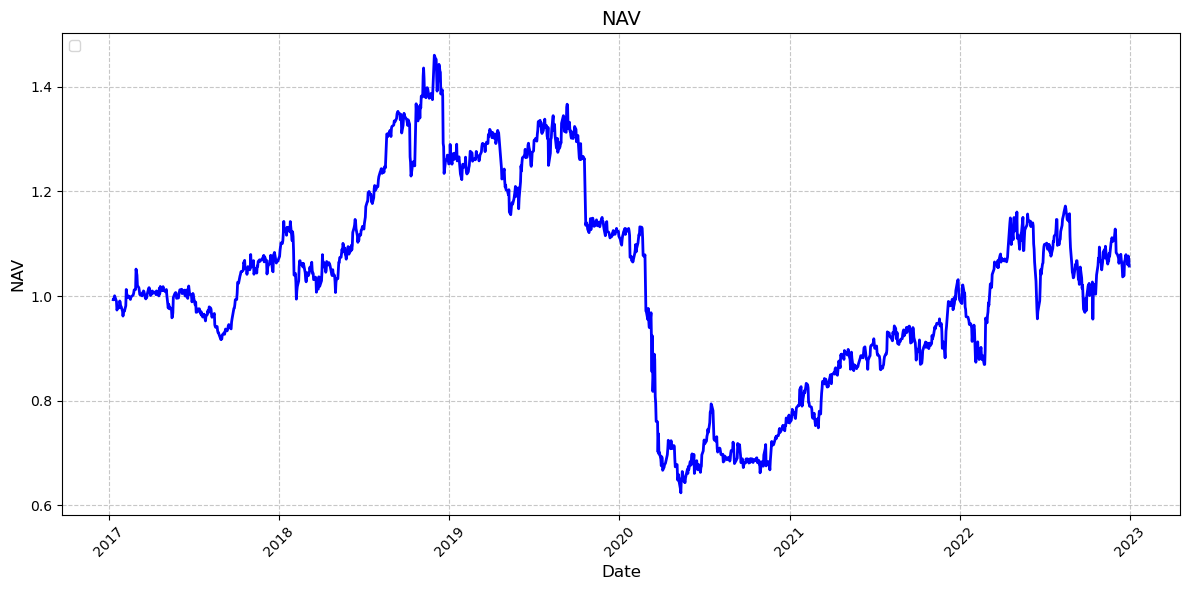

In [26]:
result['Ret'] = result['Ret'].astype(float)
result['NAV'] = (1 + result['Ret']).cumprod()
plt.figure(figsize=(12, 6))
plt.plot(result.index, result['NAV'], color='blue', linewidth=2)
plt.title('NAV', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('NAV', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()